# Grunnlag: fra referansemodell til maskinlæring

Arbeidsverk 2, notebook 01. Bygger på rapporten fra arbeidsverk 1 —
`bostotte_oslo.pdf` i [Torcode/bostotte-oslo](https://github.com/Torcode/bostotte-oslo).

Notebooken knytter analysen til et datert uttrekk, går gjennom variablene og hva
de tåler, viser hvilke fordelinger som ligger bak aggregatene, og regner ut hvor
mye informasjon panelet inneholder.

Ingen modell estimeres her. Panelets størrelse avgjør hvilke modellklasser som er
aktuelle, så det tallet kommer først.

**Om figurer og tabeller.** Hver figur har tallene sine trykket ved siden av seg,
og for hver oppgis hvilken bevegelse som er for liten til å tolkes. Der en figur
viser et gjennomsnitt, står det hvilken fordeling over husstander som kan
produsere bildet.

**Om arbeidsformen.** Prosjektet er skrevet med KI som verktøy. Tall i teksten
kommer fra celler som kjører. Kildene har en statustabell i avsnitt 8.


## 1. Innledning

*Avsnittet står som punkter og skal skrives ut i løpende tekst, omtrent én
side. Punktene er innholdet, ikke formuleringene.*

1. **Der arbeidsverk 1 endte.** Serien er regelstyrt. Betinget på tre
   intervensjonsvinduer og to kalenderregressorer er logserien stasjonær.
   Hovedspesifikasjonen traff termin april 2024 — et fall på 25 % på én termin —
   innenfor 3 % fra ni måneders horisont. Sesongnaiv og SARIMA bommet med 25–35 %.
2. **To av fem implikasjoner falt.** T4 falt motsatt vei av forventningen:
   modellering av bruddene forverret intervalldekningen. T5 lot seg ikke teste,
   fordi det ikke finnes publiserte husstandstall for hendelsen det gjaldt.
3. **Et funn som peker framover.** Inngangsregelen slipper en regressor inn så
   snart den er teknisk estimerbar, men estimatet er svært upresist i månedene
   etter. Det finnes tre regimer: uidentifiserbar, identifisert men upålitelig,
   og identifisert og stabil. Arbeidsverk 1 skiller bare det første fra de to siste.
4. **Hvorfor Python nå.** Baselinen er bygget i R, der tidsserieverktøyet bor.
   Modellklassene som gjenstår hører hjemme i Python.
5. **Hva spørsmålet er.** Ikke om maskinlæring slår en referansemodell på én
   serie med 198 månedsobservasjoner. Avsnitt 7 gjengir hvorfor svaret på det er
   nei. Spørsmålet er om strukturen i datagrunnlaget bærer informasjon en
   enkeltseriemodell ikke når.
6. **Din egen linje inn:** hvorfor bydelsnivået er det etaten dimensjonerer på,
   og hva prognosen skal brukes til.


## 2. Oppsett og datering

Husbanken publiserer nye månedstall løpende, og reviderer bakover ved
etterkontroll mot skatteoppgjøret. Et resultat må derfor kunne knyttes til den
tilstanden dataene hadde da det ble laget.

Uttrekksskriptet kjører mot Husbankens API og lagrer hvert uttrekk i en datert
mappe. En analyse oppgir hvilken dato den bygger på, og kontrollerer sjekksummene
til filene den leser før den regner. Kontrollen kan feile; det er poenget med den.

Denne notebooken leser uttrekket som følger commit `9b3da3e`, datert
4. august 2026.


In [1]:
COMMIT   = "9b3da3e"        # arbeidsverk 1, 6. august 2026
UTTREKK  = "2026-08-04"     # datoen datagrunnlaget er hentet
REPO     = "https://github.com/Torcode/bostotte-oslo.git"

import os, subprocess

# Colab legger alt under /content; utenfor Colab klones det til arbeidsmappa.
MAPPE = "/content/bostotte-oslo" if os.path.isdir("/content") else "bostotte-oslo"

if not os.path.isdir(MAPPE):
    subprocess.run(["git", "clone", "-q", "--depth", "1", REPO, MAPPE], check=True)
os.chdir(MAPPE)

def hode():
    return subprocess.run(["git", "rev-parse", "--short", "HEAD"],
                          capture_output=True, text=True).stdout.strip()

if hode() != COMMIT:                       # main kan ha flyttet seg
    subprocess.run(["git", "fetch", "-q", "--depth", "1", "origin", COMMIT], check=True)
    subprocess.run(["git", "checkout", "-q", COMMIT], check=True)

assert hode() == COMMIT, f"Forventet {COMMIT}, fikk {hode()}"
print("arbeidsmappe :", os.getcwd())
print("commit       :", hode())
print("uttrekk      :", UTTREKK)


arbeidsmappe : /content/bostotte-oslo
commit       : 9b3da3e
uttrekk      : 2026-08-04


### Sjekksummer

Sjekksummene under er regnet av notebooken. Når datagrunnlaget flyttes til
daterte mapper, leses de i stedet fra uttrekkets eget manifest og sammenliknes,
slik at en endret fil stopper kjøringen framfor å passere ubemerket.


In [2]:
import hashlib, json
import pandas as pd

RAW    = "data/raw/"
FILER  = ["husbanken_bostotte_oslo_manedlig.csv",
          "husbanken_bostotte_oslo_bydel_manedlig.csv",
          "husbanken_bostotte_oslo_brukergruppe_manedlig.csv"]

def sha256(sti, blokk=1 << 20):
    h = hashlib.sha256()
    with open(sti, "rb") as f:
        for b in iter(lambda: f.read(blokk), b""):
            h.update(b)
    return h.hexdigest()

SJEKKSUM = {f: sha256(RAW + f) for f in FILER}
pd.DataFrame({"fil": FILER,
              "bytes": [os.path.getsize(RAW + f) for f in FILER],
              "sha256": [SJEKKSUM[f][:16] + "..." for f in FILER]})


,fil,bytes,sha256
0,husbanken_bostotte_oslo_manedlig.csv,15072,5e741e0864bd8d66...
1,husbanken_bostotte_oslo_bydel_manedlig.csv,231775,d5dcd738bb9e23cc...
2,husbanken_bostotte_oslo_brukergruppe_manedlig.csv,90048,3b0f170c2e876364...


### Harmoni med git

Denne filen finnes to steder: i repoet under `notebooks/`, og som en Colab-kopi i
Drive. Kopier går fra hverandre uten at noen merker det, så cellen under spør
GitHub hva som ligger på `main` og sammenlikner.

Sammenlikningen går på **kildeteksten** i cellene — kode og prosa, ikke utdata, som
uansett endrer seg ved hver kjøring. Avtrykket er stemplet inn ved bygging, og cellen
selv holdes utenfor regnestykket, ellers ville den endret sitt eget svar. Kontrollen
svarer derfor på ett spørsmål: *er denne kopien bygget fra samme revisjon som den på
`main`?* Den ser ikke om noen har redigert cellene i akkurat denne kopien etterpå.


In [3]:
# harmoni-med-git: denne cellen holdes utenfor sitt eget avtrykk
KILDEAVTRYKK = "04483b532666ea0e0efeacd48c6c7d24221373b6ebfa0c1915f7825ed52dc861"
RAATT = ("https://raw.githubusercontent.com/Torcode/bostotte-oslo/"
         "main/notebooks/bostotte_01_grunnlag.ipynb")
LOGG  = ("https://api.github.com/repos/Torcode/bostotte-oslo/commits"
         "?path=notebooks/bostotte_01_grunnlag.ipynb&per_page=1")

import urllib.request, urllib.error

def kildeavtrykk(celler):
    ut = []
    for c in celler:
        kilde = c["source"] if isinstance(c["source"], str) else "".join(c["source"])
        if "harmoni-med-git" not in kilde:
            ut.append(kilde)
    return hashlib.sha256("\n".join(ut).encode("utf-8")).hexdigest()

def hent(url, sekunder=25):
    with urllib.request.urlopen(url, timeout=sekunder) as r:
        return json.load(r)

# Datoen er pynt og hentes fra et annet endepunkt; den faar ikke velte kontrollen.
try:    NAAR = " (sist endret " + hent(LOGG)[0]["commit"]["committer"]["date"][:10] + ")"
except Exception: NAAR = ""

try:
    paa_main = kildeavtrykk(hent(RAATT)["cells"])
    I_HARMONI = paa_main == KILDEAVTRYKK
    MANIFEST_HARMONI = "i harmoni" if I_HARMONI else "avvik mot main"
    if I_HARMONI:
        print(f"I harmoni med main{NAAR}.")
    else:
        print("AVVIK: denne kopien er bygget fra en annen revisjon enn main.")
        print(f"  denne : {KILDEAVTRYKK[:16]}...")
        print(f"  main  : {paa_main[:16]}...{NAAR}")
        print("  nyeste: https://github.com/Torcode/bostotte-oslo/blob/main/"
              "notebooks/bostotte_01_grunnlag.ipynb")
except Exception as e:
    MANIFEST_HARMONI = f"ikke sjekket ({type(e).__name__})"
    print(f"Kontrollen naadde ikke GitHub ({type(e).__name__}). "
          "Da vet vi ikke om kopien er aktuell; anta at den ikke er det.")


AVVIK: denne kopien er bygget fra en annen revisjon enn main.
  denne : 04483b532666ea0e...
  main  : e81f9c00738f2a08...
  nyeste: https://github.com/Torcode/bostotte-oslo/blob/main/notebooks/bostotte_01_grunnlag.ipynb


### Miljøstempel

Colab bytter pakkeversjoner uten varsel. Stempelet noterer hvilke versjoner som
produserte tallene.


In [4]:
import platform, importlib

MANIFEST = {"commit": COMMIT, "uttrekk": UTTREKK,
            "python": platform.python_version(),
            "pakker": {}, "sjekksum": SJEKKSUM}
for p in ["numpy", "pandas", "sklearn", "scipy", "matplotlib"]:
    try:    MANIFEST["pakker"][p] = importlib.import_module(p).__version__
    except ImportError: MANIFEST["pakker"][p] = None

print(json.dumps({k: MANIFEST[k] for k in ["commit","uttrekk","python","pakker"]},
                 indent=2))


{
  "commit": "9b3da3e",
  "uttrekk": "2026-08-04",
  "python": "3.11.15",
  "pakker": {
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "sklearn": "1.8.0",
    "scipy": "1.17.1",
    "matplotlib": "3.10.9"
  }
}


In [5]:
import itertools
import numpy as np, matplotlib.pyplot as plt

SEED = 20260807
np.random.seed(SEED)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

# Kategorisk palett med validert rekkefølge: verste nabopar har dE 9.1 ved
# protanopi og 19.6 for normalsyn. Tre av slottene ligger under 3:1 kontrast mot
# hvit flate, og krever derfor synlige etiketter eller tall ved siden av figuren.
SERIE   = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
BLEKK, BLEKK_2, DEMPET = "#0b0b0b", "#52514e", "#898781"
RUTE, BASIS = "#e1e0d9", "#c3c2b7"
NB, HARDT = chr(10), chr(160)

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 130, "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.size": 8.5, "axes.titlesize": 9.5, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 8,
    "text.color": BLEKK, "axes.labelcolor": BLEKK_2,
    "xtick.color": DEMPET, "ytick.color": DEMPET,
    "xtick.labelcolor": BLEKK_2, "ytick.labelcolor": BLEKK_2,
    "axes.edgecolor": BASIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": RUTE, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 7.5,
    "lines.linewidth": 1.6, "lines.solid_capstyle": "round",
})

def tusen(v, _=None):
    return f"{v:,.0f}".replace(",", HARDT)

KORT = {"Husstander med midlertidige trygdeytelser": "Midlertidige ytelser",
        "Husstander uten trygdeytelser": "Uten trygdeytelser",
        "Uføre forøvrig": "Uføre forøvrig", "Unge uføre": "Unge uføre",
        "Eldre": "Eldre"}

print("seed satt, figurstil satt")


seed satt, figurstil satt


## 3. Dataene og variablene

Uttrekket har tre nivåer av samme størrelse: Oslo totalt, Oslo fordelt på 15
bydeler pluss en ufordelt restnode, og Oslo fordelt på 5 brukergrupper. Alle tre
kommer fra Husbankens statistikkbank, hentet med Qlik Engine-API-et.


In [6]:
def les(fil, nøkler):
    d = pd.read_csv(RAW + fil, dtype={"kommunenr": str})
    d["dato"] = pd.to_datetime(dict(year=d.aar, month=d.manedsnr, day=1))
    return d.sort_values(nøkler + ["dato"]).reset_index(drop=True)

oslo  = les(FILER[0], [])
bydel = les(FILER[1], ["kommunenr"])
bgr   = les(FILER[2], ["brukergruppe"])

for navn, d in [("oslo", oslo), ("bydel", bydel), ("brukergruppe", bgr)]:
    print(f"{navn:13s} {len(d):6d} rader   {d.dato.min():%Y-%m} – {d.dato.max():%Y-%m}")


oslo             199 rader   2010-01 – 2026-07
bydel           3022 rader   2010-01 – 2026-07
brukergruppe     995 rader   2010-01 – 2026-07


Radtallene er første kontroll av at filene er hele. Oslo har én rad per måned,
bydelsfila seksten ganger så mange, brukergruppefila fem. Alle tre dekker samme
periode; gjør de ikke det, er et uttrekk avkortet.


### Hva én rad er

Én rad er én måned for én enhet. Utfallsvariabelen er `ant_husstander_termin`,
antall unike husstander med positivt terminvedtak for måneden.

To kalendre må holdes fra hverandre:

| Kalender | Kolonne | Hva den daterer |
|---|---|---|
| Termin | `ant_husstander_termin` | måneden vedtaket gjelder |
| Utbetaling | `ant_husstander_utbetaling` | måneden pengene utbetales, den 20. måneden etter |

Arbeidsverk 1 modellerer terminkalenderen. Den svarer på hvor mange husstander
som har rett til bostøtte en gitt måned.

Forvekslingen er ikke hypotetisk. SØF-rapport 05/2025 daterer avviklingen av det
midlertidige regelverket til mai 2024; dette arbeidet daterer den til termin
april 2024. Begge er riktige, fordi termin april utbetales 20. mai. To kilder
omtaler samme hendelse med én måneds forskjell, og forskjellen er hvilken
kalender de bruker.

Cellen kontrollerer identiteten mellom de to.


In [7]:
k = oslo[["dato", "ant_husstander_termin", "ant_husstander_utbetaling"]].copy()
k["utb_neste"]  = k["ant_husstander_utbetaling"].shift(-1)
k["differanse"] = k["ant_husstander_termin"] - k["utb_neste"]
t = k.dropna(subset=["utb_neste"]).query("ant_husstander_termin > 0")

print(f"måneder testet           : {len(t)}")
print(f"måneder med differanse 0 : {(t.differanse == 0).sum()}")
print(f"største avvik            : {t.differanse.abs().max():.0f}")
assert (t.differanse == 0).all(), "Kalenderidentiteten holder ikke"


måneder testet           : 198
måneder med differanse 0 : 198
største avvik            : 0


Null avvik i samtlige måneder. De to kolonnene er samme størrelse forskjøvet én
måned, ikke to målinger som tilfeldigvis ligner. Det er også grunnen til at
`ant_husstander_utbetaling` ikke kan brukes som prediktor — den inneholder ingen
informasjon utover terminserien.


### Variablene, og hva de tåler

To av kolonnene er ikke selvstendig informasjon, og fire er gjennomsnitt over en
gruppe hvis grense settes av regelverket. Avsnitt 4 viser hva det siste betyr i
praksis.


In [8]:
pd.DataFrame([
 ("ant_husstander_termin",    "beholdning", "utfall",
  "Prognoseobjektet. Nivået er resultatet av inn- og utstrømning."),
 ("ant_husstander_utbetaling","beholdning", "kalenderkontroll",
  "Samme størrelse forskjøvet én måned."),
 ("ant_soknader",             "strøm",      "ikke prediktor",
  "Behandlede saker = innvilget + avslag. Lineærkombinasjon av utfallet."),
 ("ant_avslag",               "strøm",      "diagnostikk",
  "Del av samme identitet."),
 ("utbetalt_belop",           "sum",        "sekundærutfall",
  "Måler omregnet rett, ikke utbetalt kasse."),
 ("gjsnitt_bostotte",         "snitt",      "grensesensitiv",
  "Snitt over mottakerne. Følger hvor regelverket setter grensen."),
 ("gjsnitt_inntekt_mnd",      "snitt",      "grensesensitiv", "Samme."),
 ("gjsnitt_boutgift_mnd",     "snitt",      "grensesensitiv", "Samme."),
 ("ant_over_tak",             "antall",     "grensesensitiv",
  "Avhenger av takets nivå og av hvem som er innenfor."),
], columns=["kolonne", "type", "rolle", "merknad"])


,kolonne,type,rolle,merknad
0,ant_husstander_termin,beholdning,utfall,Prognoseobjektet. Nivået er resultatet av inn-...
1,ant_husstander_utbetaling,beholdning,kalenderkontroll,Samme størrelse forskjøvet én måned.
2,ant_soknader,strøm,ikke prediktor,Behandlede saker = innvilget + avslag. Lineærk...
3,ant_avslag,strøm,diagnostikk,Del av samme identitet.
4,utbetalt_belop,sum,sekundærutfall,"Måler omregnet rett, ikke utbetalt kasse."
5,gjsnitt_bostotte,snitt,grensesensitiv,Snitt over mottakerne. Følger hvor regelverket...
6,gjsnitt_inntekt_mnd,snitt,grensesensitiv,Samme.
7,gjsnitt_boutgift_mnd,snitt,grensesensitiv,Samme.
8,ant_over_tak,antall,grensesensitiv,Avhenger av takets nivå og av hvem som er inne...


## 4. Aggregatet og fordelingen bak

Filen har to kalendre i samme rad, og hvilken kolonne som følger hvilken avgjør
alt som sammenliknes. `ant_husstander_termin` daterer rettighetsmåneden.
Beløps- og snittkolonnene føres i utbetalingskalenderen — kodeboken sier det for
`utbetalt_belop` og `ant_over_tak`, og cellen under prøver det på dataene.

Klassifiseringen hviler på tre kontroller av ulik styrke, og forskjellen i styrke
er verdt å holde fast ved.

To av dem er identiteter, altså regnestykker som enten går opp eller ikke.
Antall husstander står i begge kalendre, så terminmåneden *m* må være identisk med
utbetalingsmåneden *m+1*. Og utbetalt beløp må være antall ganger gjennomsnittlig
bostøtte — spørsmålet er bare hvilket antall, og bare den ene av de to kandidatene
kan få regnestykket til å gå opp.

Den tredje er svakere, og gjelder de kolonnene ingen identitet dekker. Der finnes
bare et indisium, og avviklingen av den midlertidige egenandelen i termin april 2024
gir det: en terminkolonne må brekke i april, en utbetalingskolonne i mai. Testen
spør hvilken av de to månedene som bærer det største utslaget, og krever at
forspranget er stort nok til å avgjøre noe. Der det ikke er det, står kolonnen som
uavgjort.


In [9]:
UTBETALINGSKALENDER = {"ant_husstander_utbetaling", "utbetalt_belop",
                       "gjsnitt_bostotte", "gjsnitt_inntekt_mnd",
                       "gjsnitt_boutgift_mnd", "ant_over_tak"}

oi  = oslo[oslo.ant_husstander_termin > 0].set_index("dato").sort_index()
KOL = ["ant_husstander_termin"] + sorted(UTBETALINGSKALENDER - {"ant_husstander_utbetaling"})

# 1. Identiteten: termin(m) == utbetaling(m+1), rad for rad.
tvilling = pd.concat([oi.ant_husstander_termin,
                      oi.ant_husstander_utbetaling.shift(-1)], axis=1).dropna()
kal_avvik = (tvilling.iloc[:, 0] - tvilling.iloc[:, 1]).abs()
N_PAR, N_AVVIK = len(tvilling), int((kal_avvik > 0).sum())
assert N_AVVIK == 0, f"identiteten brister i {N_AVVIK} maaneder"
print(f"Identitet termin(m) = utbetaling(m+1): {N_PAR} par, {N_AVVIK} avvik.")

# 2. Beloepsidentiteten: utbetalt_belop = antall x gjsnitt_bostotte. Hvilket antall?
def relavvik(tellekolonne):
    anslag = oi[tellekolonne] * oi["gjsnitt_bostotte"]
    return ((anslag - oi["utbetalt_belop"]).abs() / oi["utbetalt_belop"]).max()

A_UTB, A_TER = relavvik("ant_husstander_utbetaling"), relavvik("ant_husstander_termin")
assert A_UTB < 1e-4 < A_TER, "beloepsidentiteten peker ikke paa utbetalingskalenderen"
print(f"Identitet beloep = antall x snitt: maks relativt avvik "
      f"{A_UTB:.1e} mot utbetaling, {100*A_TER:.0f} % mot termin.\n")

# 3. Resten: hvilken av de to kandidatmaanedene baerer utslaget?: hvilken av de to kandidatmaanedene baerer utslaget?
APRIL, MAI = pd.Timestamp("2024-04-01"), pd.Timestamp("2024-05-01")
SKILLEKRAV = 3.0   # forspranget maa vaere minst tre ganger for aa avgjoere noe

def utslag(kol, mnd):
    return abs(np.log(oi[kol].where(oi[kol] > 0)).diff().loc[mnd])

rad = []
for k in KOL:
    a, m = utslag(k, APRIL), utslag(k, MAI)
    stor, liten = max(a, m), min(a, m)
    forhold = stor / liten if liten > 0 else np.inf
    avgjort = forhold >= SKILLEKRAV
    peker = ("termin" if a > m else "utbetaling") if avgjort else "—"
    sier  = "utbetaling" if k in UTBETALINGSKALENDER else "termin"
    assert not avgjort or peker == sier, f"{k}: dataene peker paa {peker}, ikke {sier}"
    rad.append((sier, f"{100*a:.1f} %", f"{100*m:.1f} %",
                f"{forhold:.0f}x" if np.isfinite(forhold) else "—", peker))

kal = pd.DataFrame(rad, index=KOL,
                   columns=["klassifisert", "april 2024", "mai 2024",
                            "forsprang", "dataene peker paa"])
kal.index.name = None
n_avgjort = (kal["dataene peker paa"] != "—").sum()
print(f"Bruddtesten avgjoer {n_avgjort} av {len(KOL)} kolonner, alle i favoer av")
print("klassifiseringen. Den siste beveger seg for likt i de to maanedene.\n")
kal


Identitet termin(m) = utbetaling(m+1): 197 par, 0 avvik.
Identitet beloep = antall x snitt: maks relativt avvik 1.6e-06 mot utbetaling, 25 % mot termin.

Bruddtesten avgjoer 5 av 6 kolonner, alle i favoer av
klassifiseringen. Den siste beveger seg for likt i de to maanedene.



,klassifisert,april 2024,mai 2024,forsprang,dataene peker paa
ant_husstander_termin,termin,29.1 %,4.8 %,6x,termin
ant_over_tak,utbetaling,1.3 %,29.3 %,23x,utbetaling
gjsnitt_bostotte,utbetaling,0.2 %,5.7 %,24x,utbetaling
gjsnitt_boutgift_mnd,utbetaling,0.7 %,0.9 %,1x,—
gjsnitt_inntekt_mnd,utbetaling,0.2 %,17.5 %,81x,utbetaling
utbetalt_belop,utbetaling,1.3 %,23.4 %,18x,utbetaling


Den første identiteten holder i alle 197 par uten ett eneste avvik. Forskyvningen er
dermed ikke et anslag: den er nøyaktig én måned, og retningen er kjent. Filranden
viser det samme uten at noe må regnes: i første rad står utbetalingskolonnene på null,
fordi utbetalingen som hører hjemme der gjelder en termin fra før uttrekket begynner.
Det er også grunnen til at identiteten har 197 par og ikke 198 — siste termin er ikke
utbetalt innenfor uttrekket.

Den andre skiller like skarpt. Regnestykket går opp til under to milliondeler når
antallet hentes fra utbetalingsmåneden, og bommer med opptil 25 prosent når det
hentes fra terminmåneden. Resten er avrunding av snittet. Det plasserer både
`utbetalt_belop` og `gjsnitt_bostotte` i utbetalingskalenderen: de må stå i samme
måned som antallet de multipliseres med.

Bruddtesten legger til `ant_over_tak` og `gjsnitt_inntekt_mnd`, som ingen identitet
dekker, og bekrefter de fire første på nytt. Gjennomsnittlig boutgift er den eneste
som blir stående uavgjort — 0,7 mot 0,9 prosent skiller ingenting — og den er da
også ført opp som uavgjort framfor å bli talt som bekreftet. Den er klassifisert
etter kodeboken alene, og brukes ikke til noe som avhenger av hvilken måned den
dateres i. Alle tre kontrollene er `assert`, så en kolonne som peker motsatt vei
stopper kjøringen i stedet for å gå stille videre inn i alt som bygger på den.

Funksjonen under henter en verdi for en gitt **termin**måned uansett hvilken kalender
kolonnen føres i. Den finnes fordi feilen den forhindrer allerede er gjort én gang i
dette arbeidet — se avsnitt 9.


In [10]:
def paa_termin(kol, terminmnd):
    m = (terminmnd + pd.DateOffset(months=1)
         if kol in UTBETALINGSKALENDER else terminmnd)
    return oi.loc[m, kol]

BRUDD = pd.Timestamp("2024-04-01")
FOER  = pd.Timestamp("2024-03-01")

april = pd.DataFrame({
    "termin mars 2024": [paa_termin(k, FOER) for k in KOL],
    "termin april 2024": [paa_termin(k, BRUDD) for k in KOL],
}, index=KOL).round(0)
april["endring"] = ((100*(april.iloc[:, 1]/april.iloc[:, 0] - 1))
                    .round(1).astype(str) + " %")
april.index.name = None
april


,termin mars 2024,termin april 2024,endring
ant_husstander_termin,20849.0,15588.0,-25.2 %
ant_over_tak,17809.0,13292.0,-25.4 %
gjsnitt_bostotte,3767.0,3987.0,5.8 %
gjsnitt_boutgift_mnd,12615.0,12728.0,0.9 %
gjsnitt_inntekt_mnd,17785.0,14929.0,-16.1 %
utbetalt_belop,78543373.0,62141786.0,-20.9 %


En fjerdedel av mottakerne forsvant på én termin. De som ble igjen har
**16 prosent lavere snittinntekt** og får **6 prosent mer i bostøtte**. Antallet med
boutgifter over taket faller like mye som antallet mottakere, mens
gjennomsnittlig boutgift står stille.

Mønsteret peker på hvem som falt ut: husstandene med høyest inntekt. Det er også
det regelverket tilsier. Intervensjon I05 i `intervensjonstabell.csv` senket det
progressive egenandelsleddet fra 0,28 % til 0,12 % i termin desember 2021, noe som
løftet den implisitte inntektsgrensen. Da leddet ble ført tilbake i termin april
2024, var det husstandene nærmest den grensen som mistet retten.

Brukergruppene lar påstanden testes.


In [11]:
def gruppe(kol):
    return (bgr[bgr.ant_husstander_termin > 0]
            .pivot_table(index="dato", columns="brukergruppe", values=kol, aggfunc="sum")
            .sort_index())

G, GI, GB = gruppe("ant_husstander_termin"), gruppe("gjsnitt_inntekt_mnd"), gruppe("gjsnitt_bostotte")

# Kalenderen foelger kolonnen, ikke tabellen: antallet hentes i terminmaaneden,
# snittene en maaned senere. Samme regel som paa_termin, paa gruppenivaa.
def gruppe_paa_termin(ramme, kol, terminmnd):
    return ramme.loc[terminmnd + pd.DateOffset(months=1)
                     if kol in UTBETALINGSKALENDER else terminmnd]

n0 = gruppe_paa_termin(G,  "ant_husstander_termin", FOER)
n1 = gruppe_paa_termin(G,  "ant_husstander_termin", BRUDD)
i0 = gruppe_paa_termin(GI, "gjsnitt_inntekt_mnd",   FOER)
i1 = gruppe_paa_termin(GI, "gjsnitt_inntekt_mnd",   BRUDD)
b0 = gruppe_paa_termin(GB, "gjsnitt_bostotte",      FOER)
b1 = gruppe_paa_termin(GB, "gjsnitt_bostotte",      BRUDD)

# Alt bygges i ett uttrykk saa pandas justerer paa gruppenavn. Ingen .values,
# ingen kolonne satt inn etter at raden er sortert eller doept om.
test = (pd.DataFrame({
            "mottakere før":    n0.round(0),
            "tap %":            (100*(n1/n0 - 1)).round(1),
            "snittinntekt før": i0.round(0),
            "inntekt %":        (100*(i1/i0 - 1)).round(1),
            "bostøtte %":       (100*(b1/b0 - 1)).round(1),
            # Hva de som gikk maatte tjent for at snittet skulle flytte seg slik.
            # Forutsetter null tilsig og uendret inntekt hos dem som ble.
            "snitt blant dem som gikk": ((n0*i0 - n1*i1) / (n0 - n1)).round(0),
            # Hvor stor del av Oslos samlede fall gruppen staar for.
            "andel av fallet %": (100*(n0 - n1)/(n0 - n1).sum()).round(1),
        })
        .rename(index=KORT)
        .sort_values("tap %"))
test.index.name = None

# Gruppene skal summere til aggregatet. Gjoer de ikke det, er en gruppe borte.
assert abs((n0 - n1).sum() - (paa_termin("ant_husstander_termin", FOER)
                              - paa_termin("ant_husstander_termin", BRUDD))) < 1

x, y = test["snittinntekt før"].values, test["tap %"].values
R_INNTEKT_TAP = np.corrcoef(x, y)[0, 1]
rang = lambda v: pd.Series(v).rank().values
RHO = np.corrcoef(rang(x), rang(y))[0, 1]

# Eksakt test: fem grupper gir 120 tilordninger, saa hele nullfordelingen kan telles.
tilordninger = list(itertools.permutations(y))
P_R   = np.mean([abs(np.corrcoef(x, p)[0, 1]) >= abs(R_INNTEKT_TAP) - 1e-12
                 for p in tilordninger])
P_RHO = np.mean([abs(np.corrcoef(rang(x), rang(p))[0, 1]) >= abs(RHO) - 1e-12
                 for p in tilordninger])

print(f"Pearson  r = {R_INNTEKT_TAP:+.2f}   eksakt p = {P_R:.3f}")
print(f"Spearman ρ = {RHO:+.2f}   eksakt p = {P_RHO:.3f}   "
      f"({len(tilordninger)} tilordninger, n = {len(test)})\n")
test


Pearson  r = -0.88   eksakt p = 0.033
Spearman ρ = -1.00   eksakt p = 0.017   (120 tilordninger, n = 5)



,mottakere før,tap %,snittinntekt før,inntekt %,bostøtte %,snitt blant dem som gikk,andel av fallet %
Unge uføre,1344,-58.2,28352.0,-4.3,-1.5,29238.0,14.9
Uføre forøvrig,4091,-40.7,23153.0,-9.8,7.1,26445.0,31.7
Midlertidige ytelser,6353,-30.3,21254.0,-2.1,-2.0,22269.0,36.6
Eldre,2382,-15.1,20297.0,-5.8,-5.1,26943.0,6.8
Uten trygdeytelser,6679,-7.9,8176.0,-28.4,3.0,35222.0,10.0


### Hva tabellen viser

De to første kolonnene er rangert likt. Sorterer man gruppene etter hvor stor andel
de mistet, står de samtidig sortert etter inntektsnivået sitt før bruddet, uten et
eneste bytte. Unge uføre lå høyest med 28 352 kroner i måneden og mistet nesten seks
av ti. Husstander uten trygdeytelser lå lavest med 8 176 og mistet under åtte prosent.

Fem grupper er få nok til at hele nullfordelingen kan telles ut. Det finnes 120 måter
å pare tapstallene med inntektsnivåene på, og to av dem gir en rangering uten bytter;
fire når man i stedet krever en Pearson-korrelasjon minst like sterk som −0,88.
Sannsynlighetene 2/120 og 4/120 er dermed eksakte, ikke tilnærminger, og cellen over
regner dem ut ved å gå gjennom alle 120. De sier hvor uvanlig mønsteret er dersom
inntekt og tap ikke henger sammen. De sier ikke at inntekt er årsaken.

At unge uføre ligger høyest i inntekt følger av ytelsen: uføretrygd etter
ung-ufør-satsen er høyere enn ordinær minsteytelse. Gruppen lå dermed nærmest
inntektsgrensen, og det var grensen som flyttet seg.

Kolonnen «snitt blant dem som gikk» oversetter det samme til kroner. Den spør hva
de som forsvant måtte ha
tjent for at gruppesnittet skulle flytte seg akkurat slik det gjorde, og forutsetter
at ingen kom til og at ingen av dem som ble fikk endret inntekt. Ingen av delene
holder i en vanlig måned, så tallet er ingen måling. Nytten er at det gjør størrelsen
lesbar: husstander uten trygdeytelser mistet 528 av 6 679 mottakere, men snittinntekten
i gruppen falt 28 prosent, og det lar seg bare regne fram hvis de 528 lå over fire
ganger så høyt som gruppens eget snitt. Der ligger forklaringen på at gruppen med det
minste frafallet har det største fallet i snittinntekt. Alle fem gruppene peker samme
vei.

Rate og volum er to spørsmål. Kolonnen «andel av fallet» svarer på det andre: unge
uføre mistet
størst andel, men er den minste gruppen og står bare for 15 prosent av husstandene som
forsvant. Midlertidige ytelser og uføre forøvrig står til sammen for sju av ti. Summen
er kontrollert mot aggregatet i cellen over, så en gruppe kan ikke falle ut av
regnskapet uten at kjøringen stopper.

**Forbeholdet.** Aggregater identifiserer ikke hvem som falt ut, bare hvordan snittet
flyttet seg. Mønsteret er forenlig med at de høyeste inntektene mistet retten, men
også med andre sammensetningsendringer som gir samme snitt, og fem punkter kan ikke
skille inntekt fra noe annet som følger gruppeinndelingen.

Det generelle poenget er metodisk. Snittvariablene beskriver hvor regelverket setter
grensen, ikke menneskene innenfor: to ulike fordelinger kan gi samme snitt, og
aggregatet kan ikke skille dem. Det er også grunnen til at de ikke kan brukes som
prediktorer. De bestemmes av de samme regelendringene som utfallet, og en modell som
bruker dem, predikerer med en funksjon av det den skal forklare.


/tmp/ipykernel_4677/230486163.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


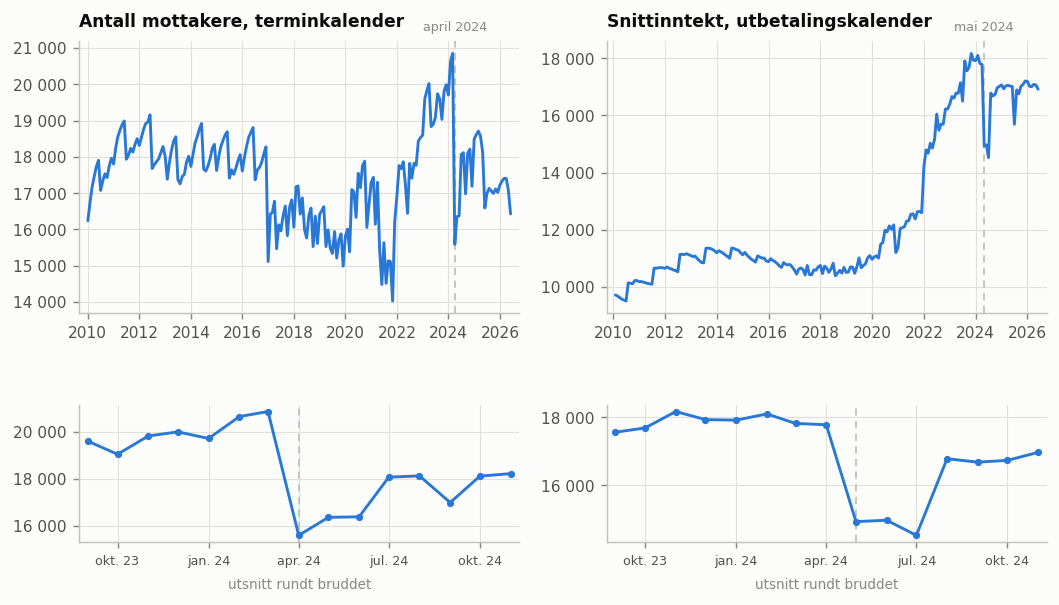

In [12]:
o = oi.reset_index()
serier = [("ant_husstander_termin", "Antall mottakere, terminkalender"),
          ("gjsnitt_inntekt_mnd",   "Snittinntekt, utbetalingskalender")]
LUPE = (pd.Timestamp("2023-09-01"), pd.Timestamp("2024-11-01"))
MND  = {4: "april", 5: "mai"}

fig, akser = plt.subplots(2, 2, figsize=(9.6, 5.0),
                          gridspec_kw={"height_ratios": [2, 1], "hspace": 0.45})
for kolonne, (kol, tittel) in enumerate(serier):
    strek = BRUDD + pd.DateOffset(months=1) if kol in UTBETALINGSKALENDER else BRUDD
    for rad in (0, 1):
        ax = akser[rad, kolonne]
        v  = o if rad == 0 else o[(o.dato >= LUPE[0]) & (o.dato <= LUPE[1])]
        ax.plot(v.dato, v[kol], color=SERIE[0],
                marker="" if rad == 0 else "o", ms=3.0)
        ax.axvline(strek, color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
        ax.margins(x=0.02)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(tusen))
    akser[0, kolonne].set_title(tittel)
    akser[0, kolonne].annotate(
        f"{MND[strek.month]} {strek.year}", xy=(strek, 1.0),
        xycoords=("data", "axes fraction"), xytext=(0, 4),
        textcoords="offset points", ha="center", va="bottom",
        fontsize=7, color=DEMPET, annotation_clip=False)
    lup = akser[1, kolonne]
    lup.set_xticks(pd.date_range("2023-10-01", "2024-10-01", freq="3MS"))
    lup.set_xticklabels(["okt. 23", "jan. 24", "apr. 24", "jul. 24", "okt. 24"],
                        fontsize=7)
    lup.set_xlabel("utsnitt rundt bruddet", fontsize=7.5, color=DEMPET, labelpad=6)

fig.tight_layout(); plt.show()


Den stiplede linja står i **april i venstre rute og mai i høyre** — samme termin,
to kalendre. Nederste rad er utsnittet rundt bruddet, der én måned er bred nok til
å ses; på seksten års akse er forskyvningen usynlig. Uten den ser høyre rute
uendret ut i bruddmåneden, og det var nettopp den lesningen som ga feil konklusjon
i en tidligere versjon.

Begge seriene faller, og de faller sammen. Fordelingen bak er likevel bare synlig
i brukergruppeinndelingen, som er den eneste oppløsningen uttrekket tilbyr.


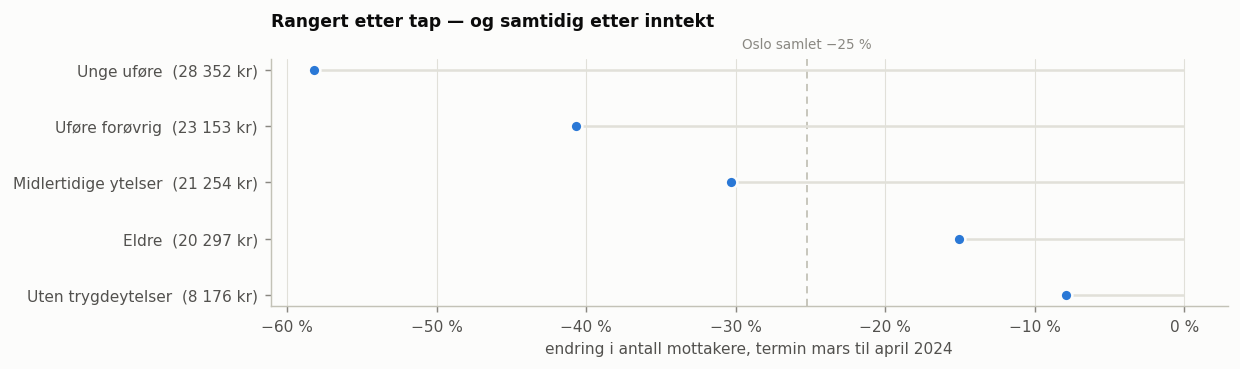

In [13]:
d = test.sort_values("tap %", ascending=False)
oslo_pst = 100*(paa_termin("ant_husstander_termin", BRUDD) /
                paa_termin("ant_husstander_termin", FOER) - 1)

fig, ax = plt.subplots(figsize=(9.6, 2.9))
y = np.arange(len(d))
ax.hlines(y, 0, d["tap %"], color=RUTE, lw=1.4)
ax.plot(d["tap %"], y, "o", ms=6.5, color=SERIE[0],
        markeredgecolor="#fcfcfb", markeredgewidth=1.4, zorder=3)
ax.axvline(oslo_pst, color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
ax.set_yticks(y, [f"{navn}  ({kr:,.0f} kr)".replace(",", HARDT)
                  for navn, kr in zip(d.index, d["snittinntekt før"])])
ax.set_xlabel("endring i antall mottakere, termin mars til april 2024")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v:.0f} %".replace("-", chr(8722))))
ax.grid(axis="y", visible=False)
ax.set_title("Rangert etter tap — og samtidig etter inntekt", pad=18)
ax.annotate(f"Oslo samlet {oslo_pst:.0f} %".replace("-", chr(8722)),
            xy=(oslo_pst, 1.0), xycoords=("data", "axes fraction"),
            xytext=(0, 4), textcoords="offset points", ha="center", va="bottom",
            fontsize=7.5, color=DEMPET, annotation_clip=False)
fig.tight_layout(); plt.show()


Figuren er den samme rangeringen som tabellen, med snittinntekten før bruddet satt
i parentes bak hvert gruppenavn. Poenget med å tegne den er at leseren kan se de to
rekkefølgene falle sammen uten å sammenlikne to kolonner: prikkene ligger i
inntektsrekkefølge fra bunn til topp. Den stiplede linja er Oslos samlede fall, og
tre av fem grupper ligger til venstre for den.

### Sammensetningen endret seg også mellom Oslo og landet

Uttrekket har de samme seriene nasjonalt. Den sammenlikningen er ikke pynt: den
avgjør om en nasjonal størrelse kan skaleres ned til Oslo med en fast andel.


In [14]:
def total(fil):
    d = pd.read_csv(RAW + fil)
    d["dato"] = pd.to_datetime(dict(year=d.aar, month=d.manedsnr, day=1))
    return (d[d.ant_husstander_termin > 0]
            .groupby("dato")["ant_husstander_termin"].sum())

andel  = (total(FILER[0]) / total("husbanken_bostotte_nasjonalt_manedlig.csv") * 100).dropna()
aarlig = andel.groupby(andel.index.year).mean().round(2)

print("Oslos andel av mottakerne nasjonalt, prosent, aarsgjennomsnitt:")
for aar in [2010, 2015, 2019, 2021, 2022, 2023, 2024, 2025, 2026]:
    if aar in aarlig.index:
        print(f"  {aar}   {aarlig[aar]:5.2f}")
print(f"\n  2010 til 2021 : {aarlig[2021] - aarlig[2010]:+5.2f} pp")
print(f"  2021 til 2024 : {aarlig[2024] - aarlig[2021]:+5.2f} pp")

ng = pd.read_csv(RAW + "husbanken_bostotte_nasjonalt_brukergruppe_manedlig.csv")
ng["dato"] = pd.to_datetime(dict(year=ng.aar, month=ng.manedsnr, day=1))
NG = (ng[ng.ant_husstander_termin > 0]
      .pivot_table(index="dato", columns="brukergruppe",
                   values="ant_husstander_termin", aggfunc="sum").sort_index())

m21, m24 = pd.Timestamp("2021-03-01"), pd.Timestamp("2024-03-01")
oppbygging = pd.DataFrame({
    "Oslo %":      (100*(G.loc[m24]/G.loc[m21] - 1)).round(0),
    "nasjonalt %": (100*(NG.loc[m24]/NG.loc[m21] - 1)).round(0),
}).rename(index=KORT)
oppbygging.index.name = None
print("\nVekst termin mars 2021 til mars 2024:")
print(oppbygging.to_string())


Oslos andel av mottakerne nasjonalt, prosent, aarsgjennomsnitt:
  2010   14.43
  2015   16.86
  2019   19.07
  2021   19.93
  2022   18.65
  2023   18.18
  2024   18.49
  2025   18.55
  2026   18.46

  2010 til 2021 : +5.50 pp
  2021 til 2024 : -1.44 pp

Vekst termin mars 2021 til mars 2024:
                      Oslo %  nasjonalt %
Eldre                   33.0         26.0
Midlertidige ytelser    44.0         72.0
Uten trygdeytelser       4.0         21.0
Uføre forøvrig          45.0         87.0
Unge uføre              88.0         50.0


Oslos andel steg hvert år fra 2010 til 2021, fra 14,4 % til 19,9 %, og falt så til
rundt 18,5 %. Oppbyggingen 2021–2024 traff ulikt: nasjonalt vokste gruppen med
midlertidige trygdeytelser 72 %, i Oslo 44 %. Unge uføre gikk motsatt vei, 88 % i
Oslo mot 50 % nasjonalt.

SØF-rapport 05/2025 oppgir at ukrainske husstander gikk fra 0,1–0,2 % av mottakerne
i 2020–21 til 13,5 % i 2024, og at bosettingen i hovedsak skjedde utenfor Oslo. Det
er en nærliggende forklaring på fallet i andelen, men den er hentet fra rapporten og
ikke kontrollert her; andelene over er regnet i cellen.

Dette har en direkte følge for arbeidsverk 1. Modell M7 skalerer nasjonale
forhåndsanslag ned til Oslo med Oslos målte andel. Den andelen er ingen konstant —
den flyttet seg 5,5 prosentpoeng oppover på elleve år og 1,4 nedover på tre. Den bør
måles ved hver prognoseopprinnelse, av samme grunn som ordensvalget gjentas der.


## 5. Kontroller

To oppdelinger av samme total. Begge skal summere til Oslo. Kontrollen kjører på
uvasket data, før sanntidskanten fjernes.


In [15]:
def sum_mot_total(df, navn):
    s = df.groupby(["aar", "manedsnr"])["ant_husstander_termin"].sum()
    t = oslo.set_index(["aar", "manedsnr"])["ant_husstander_termin"]
    felles = s.index.intersection(t.index)
    avvik  = (s[felles] - t[felles]).abs()
    print(f"{navn:14s} {len(felles):4d} måneder   {int((avvik > 0).sum())} avvik   "
          f"største {avvik.max():.0f}")
    return int((avvik > 0).sum())

feil = sum_mot_total(bydel, "bydel") + sum_mot_total(bgr, "brukergruppe")
assert feil == 0, "Oppdelingene summerer ikke til Oslo-totalen"


bydel           199 måneder   0 avvik   største 0
brukergruppe    199 måneder   0 avvik   største 0


### Hva kontrollen dekker

Alle tre uttrekkene er regnet av samme Qlik-app, med samme uttrykk over samme
faktatabell. At marginalene summerer til totalen er derfor i stor grad en
egenskap ved aggregeringen. Kontrollen fanger feil selection, feil dimensjon, og
rader som er falt bort under uttrekket. Den er ikke ekstern validering.

Den eksterne valideringen ligger i arbeidsverk 1: uttrekket målt mot Husbankens
publiserte nasjonale årstall, med avvik fra 0,00 til −2,10 % over fem år.

Én ting avgjør kontrollen likevel. `count(distinct HusstandId)` er ikke additiv
generelt — en husstand som telles i to celler samme måned ville gitt marginalsum
større enn totalen. Avviket er null i alle måneder, så klassifiseringen er entydig
per husstand og måned. Oppdelingene er da ekte partisjoner, og det er en
forutsetning for hierarkisk avstemming i notebook 05.


### Sanntidskanten

Siste måned i uttrekket er strukturell null: terminkjøringen er ikke gjort. Den
fjernes, som vaskeinngrep V1 i arbeidsverk 1.


In [16]:
print(oslo[["dato", "ant_husstander_termin"]].tail(3).to_string(index=False))

vask_v1 = lambda df: df[df.ant_husstander_termin > 0].reset_index(drop=True)
oslo_v, bydel_v, bgr_v = vask_v1(oslo), vask_v1(bydel), vask_v1(bgr)
print(f"\netter V1: {oslo_v.dato.min():%Y-%m} – {oslo_v.dato.max():%Y-%m}, "
      f"{oslo_v.dato.nunique()} måneder")


      dato  ant_husstander_termin
2026-05-01                  17075
2026-06-01                  16428
2026-07-01                      0

etter V1: 2010-01 – 2026-06, 198 måneder


## 6. Panelet

Hvor mye data maskinlæringen har, avgjør hvilke modellklasser som er forsvarlige.


In [17]:
T     = oslo_v.dato.nunique()
noder = sorted(bydel_v.kommunenr.unique())
BYDEL = [k for k in noder if k != "0301"]        # 0301 er ufordelt restnode
K_b, K_g = len(BYDEL), bgr_v.brukergruppe.nunique()
N_SERIER = 1 + len(noder) + K_g
N_OBS    = N_SERIER * T

print(f"måneder (T)                     : {T}")
print(f"bydeler                         : {K_b}   (+ restnode 0301)")
print(f"brukergrupper                   : {K_g}")
print(f"serier i hierarkiet             : {N_SERIER}")
print(f"observasjoner i marginalpanelet : {tusen(N_OBS)}")


måneder (T)                     : 198
bydeler                         : 15   (+ restnode 0301)
brukergrupper                   : 5
serier i hierarkiet             : 22
observasjoner i marginalpanelet : 4 356


Nodetallet er ikke det samme som informasjonsmengden. Bydelene og brukergruppene
er to oppdelinger av samme total, og hver oppdeling summerer til den samme serien.
Cellen regner hvor mange uavhengige retninger variasjonen har, før og etter at
byens felles bevegelse er trukket ut.


In [18]:
def bredt(df, kol):
    return (df.pivot_table(index="dato", columns=kol,
                           values="ant_husstander_termin", aggfunc="sum")
              .sort_index())

B  = bredt(bydel_v, "kommunenr")[BYDEL]
navn = (bydel_v[["kommunenr", "bydel"]].drop_duplicates()
        .set_index("kommunenr")["bydel"])

vekst      = np.log(B.where(B > 0)).diff().dropna()
vekst_oslo = (np.log(oslo_v.set_index("dato")["ant_husstander_termin"])
              .diff().reindex(vekst.index))

# Deltakelsesforholdet til egenverdiene: hvor mange uavhengige retninger som
# bærer variasjonen. Verdi 1 betyr at alle seriene beveger seg som én.
def effektiv_dimensjon(X):
    p = np.linalg.eigvalsh(X.corr().values)[::-1]
    p = p / p.sum()
    return X.corr(), 1 / (p ** 2).sum(), p[0]   # (korrmatrise, eff.dim, PC1)

R0, d0, p0 = effektiv_dimensjon(vekst)

X    = np.column_stack([np.ones(len(vekst_oslo)), vekst_oslo.values])
rest = pd.DataFrame(vekst.values - X @ np.linalg.lstsq(X, vekst.values, rcond=None)[0],
                    index=vekst.index, columns=vekst.columns)
R1, d1, _ = effektiv_dimensjon(rest)
r2 = 1 - rest.var() / vekst.var()

par = lambda R: np.median(R.values[np.triu_indices_from(R.values, 1)])
print(f"median parvis korrelasjon, vekst   : {par(R0):.2f}")
print(f"første komponent forklarer          : {p0:.1%}")
print(f"EFFEKTIV DIMENSJON, rå vekst        : {d0:.1f}  av {K_b}")
print()
print(f"Oslo-totalen forklarer av bydelsvekst: median {r2.median():.1%}   "
      f"spenn {r2.min():.1%} – {r2.max():.1%}")
print()
print(f"median parvis korrelasjon, rest     : {par(R1):.2f}")
print(f"EFFEKTIV DIMENSJON, etter fellesledd: {d1:.1f}  av {K_b}")


median parvis korrelasjon, vekst   : 0.92
første komponent forklarer          : 91.8%
EFFEKTIV DIMENSJON, rå vekst        : 1.2  av 15

Oslo-totalen forklarer av bydelsvekst: median 93.0%   spenn 79.7% – 97.1%

median parvis korrelasjon, rest     : -0.06
EFFEKTIV DIMENSJON, etter fellesledd: 11.3  av 15


Restleddet har altså mange uavhengige retninger. Neste spørsmål er om det bærer
informasjon, eller bare er små tall. Cellen regner hvordan restvariasjonen
skalerer med bydelens størrelse.


In [19]:
n  = B.loc["2024":].mean()
sd = rest.std()

# Var restleddet uavhengig telling hver måned, ville standardavviket i
# logendring vært sqrt(2/n). Sammenlikningen viser om det stemmer.
gulv = np.sqrt(2 / n)

A  = np.column_stack([np.ones(K_b), np.log(n.values)])
b  = np.linalg.lstsq(A, np.log(sd.values), rcond=None)[0]
res = np.log(sd.values) - A @ b

skala = pd.DataFrame({
    "mottakere": n.round(0),
    "sd_rest_%": (100*sd).round(2),
    "tellegulv_%": (100*gulv).round(2),
    "andel_av_gulv": (sd/gulv).round(2),
}).sort_values("mottakere")
skala.index = [navn[i] for i in skala.index]
print(skala.to_string())
print()
print(f"log(sd_rest) = {b[0]:.2f} {b[1]:+.2f} · log(n)")
print(f"  helning {b[1]:+.2f}   (−0,50 = ren skalering med 1/sqrt(n))")
print(f"  R²      {1 - res.var()/np.log(sd.values).var():.2f}   over {K_b} bydeler")


                   mottakere  sd_rest_%  tellegulv_%  andel_av_gulv
Ullern                 426.0       2.60         6.85           0.38
Vestre Aker            601.0       1.75         5.77           0.30
Nordre Aker            743.0       1.55         5.19           0.30
Nordstrand             745.0       1.39         5.18           0.27
Grorud                 884.0       1.40         4.76           0.29
Bjerke                 980.0       1.53         4.52           0.34
Østensjø              1011.0       1.43         4.45           0.32
Alna                  1173.0       1.17         4.13           0.28
Stovner               1191.0       1.15         4.10           0.28
St. Hanshaugen        1265.0       1.40         3.98           0.35
Søndre Nordstrand     1265.0       1.28         3.98           0.32
Frogner               1387.0       1.36         3.80           0.36
Sagene                1913.0       0.86         3.23           0.27
Grunerløkka           2027.0       0.81         

Ett forbehold må ryddes av veien først. Hver bydel inngår i Oslo-totalen den måles
mot, så en del av samvariasjonen er mekanisk. Cellen gjentar regnestykket med
totalen minus bydelen selv.


In [20]:
loo = []
for k in BYDEL:
    y = np.log(B.drop(columns=k).sum(axis=1)).diff().reindex(vekst.index)
    A = np.column_stack([np.ones(len(y)), y.values])
    e = vekst[k].values - A @ np.linalg.lstsq(A, vekst[k].values, rcond=None)[0]
    loo.append(1 - e.var()/vekst[k].values.var())

# Uten de tre stoerste bruddmaanedene: er fellessignalet baaret av dem alene?
uten = vekst.drop(index=[d for d in [pd.Timestamp("2024-04-01"),
                                     pd.Timestamp("2024-05-01"),
                                     pd.Timestamp("2022-01-01")] if d in vekst.index])

print(f"median R² mot Oslo-totalen              : {r2.median():.3f}")
print(f"median R² mot totalen UTEN egen bydel   : {np.median(loo):.3f}")
print(f"effektiv dimensjon, alle måneder        : {d0:.2f}")
print(f"effektiv dimensjon, uten 3 bruddmåneder : {effektiv_dimensjon(uten)[1]:.2f}")


median R² mot Oslo-totalen              : 0.930
median R² mot totalen UTEN egen bydel   : 0.921
effektiv dimensjon, alle måneder        : 1.19
effektiv dimensjon, uten 3 bruddmåneder : 1.23


### Hva tallene betyr

Fellessignalet er ikke en del–helhetseffekt: holdes bydelen utenfor totalen den måles
mot, faller median R² fra 0,929 til 0,921. Og det bæres ikke av bruddmånedene alene —
tas de tre største ut, går effektiv dimensjon fra 1,19 til 1,23.

**I rå form er panelet ikke 15 serier.** Effektiv dimensjon er 1,2 av 15. Første
hovedkomponent forklarer over 90 % av variasjonen i logvekst, og median parvis
korrelasjon mellom bydeler er 0,92. En global modell som får dette panelet uten
videre, tilpasser det samme signalet femten ganger.

Fellesbevegelsen kommer av at både regelverkskalenderen og utbetalingskalenderen
er nasjonale og treffer alle bydeler samme måned. Kalenderen virker hver eneste
måned, og bærer derfor mest.

**Restleddet er en størrelseseffekt, ikke en bydelseffekt.** Trekker man ut byens
bevegelse, faller median parvis korrelasjon til om lag null og effektiv dimensjon
stiger til over 11 av 15. Men restvariasjonen skalerer med hvor mange mottakere
bydelen har: helningen er nær −0,6, og 87 % av forskjellen mellom bydeler
forklares av størrelse alene. Ullern har færrest mottakere og størst restledd,
Grünerløkka flest og minst.

Tellegulvet er lærerikt ved å være feil. Var hver måned en uavhengig telling,
ville *variansen* i restleddet vært rundt elleve ganger større enn den er — i
standardavvik er faktoren 3,4. Serien er en beholdning: de fleste husstandene blir
stående fra måned til måned, og bare strømmen inn og ut varierer.

**Følgen for modellvalget.** De elleve retningene er reelle, men tynne. Det
svekker argumentet for at en global modell har mye å lære på bydelsnivå, og det
styrker argumentet for avstemming, siden MinT nettopp er bygget for støyende
bunnserier. Fellesbevegelsen hører til den strukturelle modellen fra arbeidsverk 1,
som kjenner regelkalenderen.


Tallene sier at bydelene beveger seg som én. Figuren viser det. Hver rute er én
bydel indeksert til januar 2019, med Oslo-totalen i grått bak, og rutene er sortert
etter mottakertall. Formen gjentar seg: samme oppbygging fra 2022, samme fall i
termin april 2024, samme flate etterpå. Det som skiller rutene er hvor mye støy som
ligger oppå, og støyen er synlig størst nederst til høyre, der bydelene er minst.

Én rute følger ikke mønsteret. Gamle Oslo ligger under den grå linja fra 2022 og
øker avstanden gjennom hele perioden — bydelen med flest mottakere er også den
eneste som taper andel systematisk, fra 13,3 % av Oslo i 2010 til 11,2 % i 2026.
Det er den typen avvik en avstemt modell skal fange og en top-down-fordeling med
historiske andeler vil bomme på.


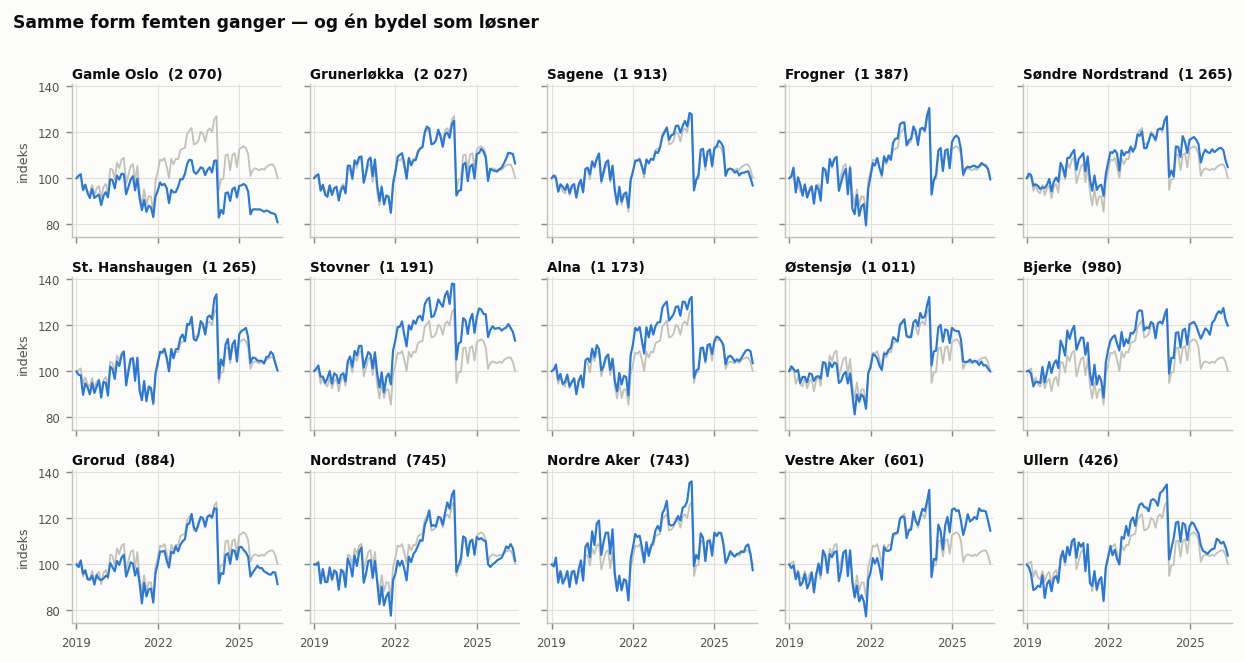

In [21]:
import matplotlib.dates as mdates

B19 = (B / B.loc["2019-01-01"] * 100).loc["2019":]
O19 = (oslo_v.set_index("dato")["ant_husstander_termin"]
       .pipe(lambda x: x / x.loc[pd.Timestamp("2019-01-01")] * 100).loc["2019":])
rekke = n.sort_values(ascending=False).index          # størst først

fig, akser = plt.subplots(3, 5, figsize=(9.6, 5.0), sharex=True, sharey=True)
for ax, kode in zip(akser.ravel(), rekke):
    ax.plot(O19.index, O19.values, color=BASIS, lw=1.0, zorder=1)
    ax.plot(B19.index, B19[kode].values, color=SERIE[0], lw=1.2, zorder=2)
    ax.set_title(f"{navn[kode]}  ({n[kode]:,.0f})".replace(",", HARDT),
                 fontsize=7.5, pad=3)
    ax.tick_params(labelsize=6.5)
    ax.margins(x=0.02)
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
for ax in akser[:, 0]:
    ax.set_ylabel("indeks", fontsize=7)
fig.suptitle("Samme form femten ganger — og én bydel som løsner",
             x=0.01, ha="left", fontsize=9.5, fontweight="semibold", y=1.005)
fig.tight_layout(); plt.show()


Figuren under setter tall på det. Bydelene er rangert etter hvor stor del av
månedsbevegelsen som er byens, med mottakertallet i parentes. De to henger sammen:
bydelene med færrest mottakere ligger lavest, og det er størrelsen som forklarer
det, ikke lokale forhold.


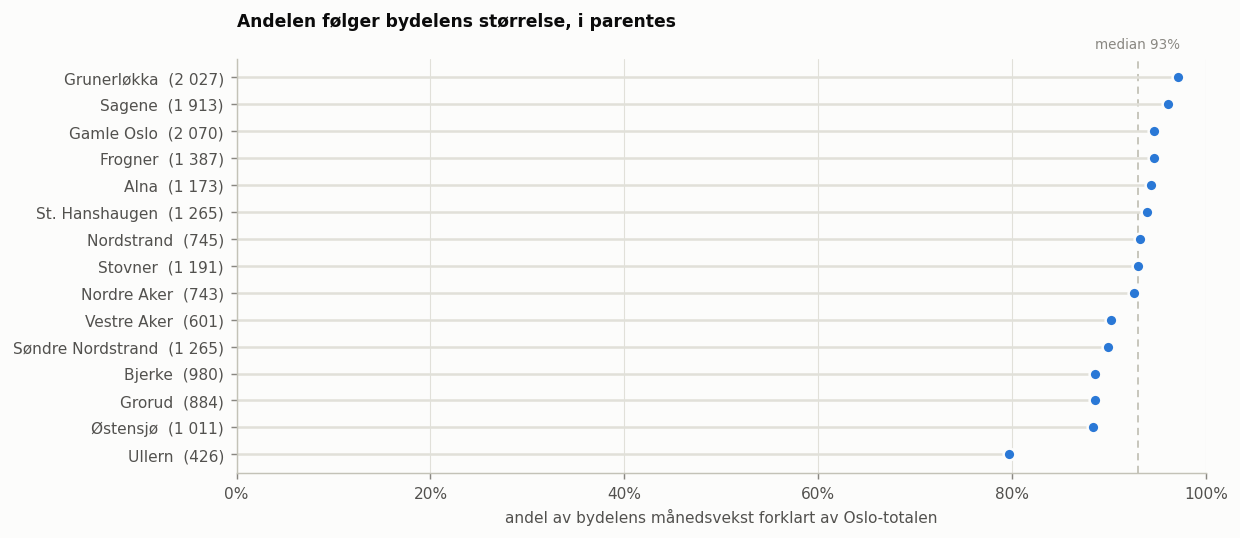

In [22]:
d = r2.sort_values()
fig, ax = plt.subplots(figsize=(9.6, 4.2))
y = np.arange(len(d))
ax.hlines(y, 0, d.values, color=RUTE, lw=1.4)
ax.plot(d.values, y, "o", ms=6.5, color=SERIE[0],
        markeredgecolor="#fcfcfb", markeredgewidth=1.4, zorder=3)
ax.axvline(d.median(), color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
ax.set_yticks(y, [f"{navn[i]}  ({n[i]:,.0f})".replace(",", HARDT) for i in d.index])
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="y", visible=False)
ax.set_xlabel("andel av bydelens månedsvekst forklart av Oslo-totalen")
ax.set_title("Andelen følger bydelens størrelse, i parentes", pad=18)
ax.annotate(f"median {d.median():.0%}", xy=(d.median(), 1.0),
            xycoords=("data", "axes fraction"), xytext=(0, 4),
            textcoords="offset points", ha="center", va="bottom",
            fontsize=7.5, color=DEMPET, annotation_clip=False)
fig.tight_layout(); plt.show()


### Krysstabellen

Husbankens Qlik-app gir også bydel × brukergruppe. Uttrekket per 4. august
inneholder den ikke. Et diagnoseuttrekk 7. august 2026 ga:

| | |
|---|---|
| bunnceller | 77 (15 bydeler × 5 grupper + restnode 0301) |
| måneder | 198, 2010m1–2026m6 |
| observasjoner | 14 879 |
| celler med full månedsdekning | 75 av 77 |
| avvik mot Oslo-totalen | 0 av 198 |
| avvik mot bydelsmarginalen | 0 av 2 997 |
| avvik mot brukergruppemarginalen | 0 av 990 |

Det tar panelet fra rundt 4 000 til rundt 15 000 observasjoner, og krysscellene
blir observert i stedet for utledet. Diagnoseuttrekket viste også at ingen av de
198 månedene hadde endret verdi siden 4. august.

Krysstabellen tas i bruk fra neste daterte uttrekk, slik at begge arbeidsverk
bygger på samme dato. To spørsmål må løses først. Restnoden 0301 har to
kryssceller med 8 og 21 måneders dekning, som er for kort til å prognostiseres og
nok til å forstyrre et kovariansestimat i avstemmingen. Og API-et leverer
uprikkede celler: 26 av 14 879 har verdien 1. Dataene er offentlig tilgjengelige
uten autentisering, så det er ingen ny utlevering, men en celle som ligger stabilt
lavt over mange måneder i én bydel og én brukergruppe gjør det mulig å følge en
husstand over tid. En undertrykkingsregel må derfor se på vedvarenhet i tillegg
til cellestørrelse.


### Brukergruppene over tid

Figuren indekserer hver gruppe til desember 2021, da det midlertidige regelverket
trådte i kraft. Tabellen under gir gulvet: en gruppes månedsbevegelse i rolige
måneder, altså hvor stort et utslag må være for å bety noe.


In [23]:
iv   = pd.read_csv("data/clean/intervensjonstabell.csv")
kant = pd.to_datetime(
    pd.Series(pd.concat([iv.termin_fra, iv.termin_til]).dropna().unique()) + "-01").values

gv    = np.log(G).diff().dropna()
mnd   = gv.index.values.astype("datetime64[D]")
naer  = np.array([bool((np.abs((m - kant.astype("datetime64[D]")).astype(int)) <= 92).any())
                  for m in mnd])

gulv = pd.DataFrame({
    "mottakere":        G.loc["2025":].mean().round(0),
    "sd_rolige_mnd_%":  (100*gv[~naer].std()).round(1),
    "april_2024_%":     (100*(G.loc[pd.Timestamp("2024-04-01")] /
                              G.loc[pd.Timestamp("2024-03-01")] - 1)).round(1),
})
gulv["utslag_i_sd"] = (gulv["april_2024_%"].abs() / gulv["sd_rolige_mnd_%"]).round(1)
gulv.index = [KORT[i] for i in gulv.index]
gulv.index.name = None
gulv


,mottakere,sd_rolige_mnd_%,april_2024_%,utslag_i_sd
Eldre,2278.0,2.2,-15.1,6.9
Midlertidige ytelser,5766.0,8.8,-30.3,3.4
Uten trygdeytelser,5996.0,5.1,-7.9,1.5
Uføre forøvrig,2905.0,4.3,-40.7,9.5
Unge uføre,515.0,5.6,-58.2,10.4


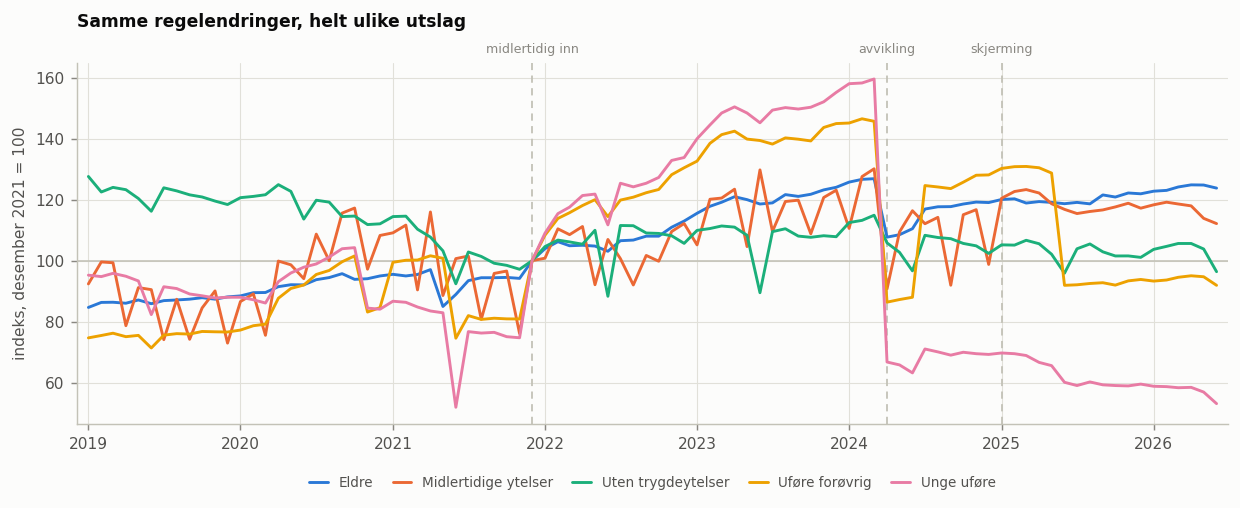

In [24]:
REF = pd.Timestamp("2021-12-01")
Gi  = (G.div(G.loc[REF]) * 100).loc["2019":]
Gi  = Gi[Gi.iloc[-1].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9.6, 4.0))
for (nvn, serie), farge in zip(Gi.items(), SERIE):
    ax.plot(Gi.index, serie, color=farge, label=KORT[nvn])
ax.axhline(100, color=BASIS, lw=0.9, zorder=1)
for dd, tekst in [(REF, "midlertidig inn"),
                  (pd.Timestamp("2024-04-01"), "avvikling"),
                  (pd.Timestamp("2025-01-01"), "skjerming")]:
    ax.axvline(dd, color=BASIS, lw=1.0, ls=(0, (4, 3)), zorder=1)
    ax.annotate(tekst, xy=(dd, 1.0), xycoords=("data", "axes fraction"),
                xytext=(0, 4), textcoords="offset points", ha="center",
                va="bottom", fontsize=7, color=DEMPET, annotation_clip=False)
ax.set_ylabel("indeks, desember 2021 = 100")
ax.set_title("Samme regelendringer, helt ulike utslag", pad=20)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.11), ncols=5,
          labelcolor=BLEKK_2, handlelength=1.4, columnspacing=1.4)
ax.margins(x=0.01)
fig.tight_layout(); plt.show()


Unge uføre er den minste gruppen, så linja svinger mest der uten at det trenger å
bety noe. Tabellen over skiller. Aprilutslaget er fra 1,5 til 10,4 ganger
gruppens normale månedsbevegelse i rolige måneder. Fire av fem ligger klart
utenfor det vanlige månedene produserer.

Den femte gjør det ikke. Husstander uten trygdeytelser falt 7,9 %, som er 1,5
ganger gruppens eget standardavvik. Det utslaget lar seg ikke skille fra normal
variasjon på dette grunnlaget alene, og skal derfor ikke leses som at avviklingen
traff gruppen svakt — bare som at figuren ikke kan avgjøre det.


## 7. Hva datamengden tillater

Modellvalget i notebook 03–05 følger av tallene i avsnitt 6. Fire resultater fra
litteraturen setter rammen.

**Globale modeller.** Montero-Manso & Hyndman (2021, *IJF* 37(4)) viser at en
global modell ikke er mer restriktiv enn lokale, og at gevinsten kommer av at
kompleksiteten kan skaleres med panelstørrelsen. De empiriske panelene i den
litteraturen ligger i hundreklassen. Her er K ≈ 20 før krysstabellen, fordelt på
to oppdelinger av samme total, og restleddet er i hovedsak en størrelseseffekt.

**Ekstrapolering.** Januschowski m.fl. (2022, *Forecasting with trees*, *IJF*
38(4)) dokumenterer at trebaserte modeller ikke ekstrapolerer utenfor
treningsområdet. Med nivåskift og trend flater prognosen ut ved siste observerte
nivå. Gradientboosting kjører derfor på differanser eller vekstrater i notebook 03.

**Residualmodellering.** Taşkaya-Temizel & Casey (2005, *Neural Networks*
18(5–6)) viser at kombinasjoner der ML modellerer en lineær modells residualer kan
prestere vesentlig dårligere enn komponentene hver for seg. Er RegARIMA-modellen
riktig spesifisert, er residualene nær hvit støy. Smyls ES-RNN, som vant M4 (2020,
*IJF* 36(1)), estimerte per-serie-nivå og et delt globalt nettverk sammen.
Notebook 03 kjører residual-ML som forhåndsregistrert negativ kontroll.

**Arkitekturvalg.** DeepAR (Salinas m.fl. 2020) og Temporal Fusion Transformer
(Lim m.fl. 2021) er validert på paneler med tusenvis av serier. Zeng m.fl. (AAAI
2023) viser at ett lineært lag slår flere transformer-varianter på standard
benchmarks. N-BEATS er dokumentert i sterkt redusert konfigurasjon, og via
zero-shot-overføring fra M4-forhåndstrening (Oreshkin m.fl., AAAI 2021).

Nevrale nett kjøres i notebook 04, med den forventede utgangen skrevet inn i
«faller dersom»-tabellen før estimering.


## 8. Hva kategoriene skjuler

*Også dette avsnittet står som punkter og skal skrives ut i løpende tekst.*

1. **Modellen ser ytelser.** Brukergruppene er administrative: eldre, unge uføre,
   uføre forøvrig, husstander med midlertidige trygdeytelser, husstander uten
   trygdeytelser. Ingen av dem sier noe om helse eller livssituasjon. NAVs
   diagnosestatistikk viser at kategoriene i stor grad er helsekategorier med en
   administrativ merkelapp, og rusdiagnoser publiseres ikke som egen gruppe.
   NOU 2022:10 foreslår å erstatte uførekriteriet i kommunenes fordelingsnøkkel
   med rus- og psykisk helse-diagnoser fra Norsk pasientregister.
2. **Tallet finnes ikke.** Ingen norsk kilde tallfester rus eller psykisk helse
   blant bostøttemottakere. Husbankens register har ingen slik variabel, og
   koblinger må gå via aggregerte bydelsandeler fra Helsedirektoratet, altså
   økologiske sammenhenger.
3. **Kategoriene fanger heller ikke innvandringsstatus.** Nasjonalt gikk
   ukrainske husstander fra 0,1–0,2 % av mottakerne i 2020–21 til 13,5 % i 2024
   (SØF 05/2025). I dataene her ser man bare at gruppen med midlertidige
   trygdeytelser vokste 72 % nasjonalt mot 44 % i Oslo. Den største
   sammensetningsendringen i perioden er usynlig i variablene.
4. **Serien måler mottak.** SSB anslår at rundt halvparten til to tredjedeler av
   de berettigede mottok bostøtte i 2016, med Oslo høyest blant storbyene.
   Ekspertgruppen fra 2022 beskriver regelverket som vanskelig å forstå. Take-up
   er selv en størrelse som beveger seg.
5. **Take-up beveger seg tregt.** Litteraturen om administrativ byrde peker på
   friksjon og kompleksitet som forklaring på ikke-bruk, og på at byrden rammer
   hardest der behovet er størst. Etter den norske reformen i 2009 ble faktisk
   opptak klart lavere enn anslått. Britiske evalueringer av satsendringer finner
   at atferdstilpasningen først slår ut etter omtrent elleve måneder.
6. **Konsekvensen for modellen.** Litteraturen predikerer asymmetrisk innfasing:
   gradvis inn over seks til tolv måneder når en regel utvider kretsen, skarpt ut
   når den innskrenker den mekanisk. Aprilfallet i avsnitt 4 er den skarpe siden
   av det. Arbeidsverk 1 har asymmetriproposisjonen med en tre måneders rampe
   testet mot AICc; nå følger en forventet størrelsesorden av litteraturen.
7. **Konsekvensen for bruken.** En modell på aggregerte månedstall for
   kapasitetsplanlegging er noe annet enn en modell som scorer enkeltpersoner.
   Notebook 06 tar det.


### Kildestatus

«Kontrollert i kildesøk» betyr at et søk oppgir å ha lest primærkilden, uten at
jeg har åpnet den selv.

| Kilde | Bruk i avsnitt 8 | Status |
|---|---|---|
| SSB Rapporter 2019/02 (Revold & With) | take-up 50–61 %, Oslo høyest | kontrollert mot primærkilde |
| Ekspertgruppen 2022 (von der Fehr m.fl.), KDD | regelverkets kompleksitet | kontrollert i kildesøk |
| NIBR 2021:10 (Dyb & Zeiner) | rus og psykisk helse blant bostedsløse | kontrollert i kildesøk |
| Velferdsetaten, Helhetlig russtatistikk 2026 | kartleggingen uke 48/2024 | kontrollert i kildesøk |
| SØF-rapport 05/2025 (Nyhus, Smedsvik & Haraldsvik) | ingen rusdata i registrene; ~25 000 husstander ut ved avviklingen | kontrollert i kildesøk |
| NAV, diagnosestatistikk uføre og AAP | hva kategoriene skjuler | ikke verifisert |
| NOU 2022:10 | forslag om diagnosekriterium | ikke verifisert |
| NOVA/Fafo 2011, 2009-reformen | opptak lavere enn anslått | kontrollert i kildesøk |
| DWP Research Report 874 (2014) | elleve måneders treghet | kontrollert i kildesøk |
| Christensen m.fl. 2020, *PAR* 80 | administrativ byrde | kontrollert i kildesøk |
| Bhargava & Manoli 2015, *AER* 105(11) | friksjon som forklaring | kontrollert i kildesøk |

De to uverifiserte radene står uten tall i teksten over.


## 9. Hva notebooken ikke gjør

- Ingen modell er estimert. Baselinen M0–M7 ligger i arbeidsverk 1 og hentes inn
  i notebook 02 gjennom eksportfilene derfra.
- Krysstabellen er kontrollert, men hører til et annet uttrekk. Den tas i bruk
  fra neste daterte uttrekk.
- Protokollkontrakten er ikke lest inn. Den krever at arbeidsverk 1 rendres med
  eksportchunken. Notebook 02 skal stoppe hvis den mangler.
- Fordelingen er bare oppløst i brukergruppedimensjonen. Uttrekket tilbyr ikke
  mer, og inntektsfordelingen innad i en gruppe er ikke observert.
- De to uverifiserte kildene står uten tall.

### En feil som ble gjort her

Første versjon av avsnitt 4 sammenliknet mars og april 2024 ved å hente alle
kolonnene i samme rad. Det ga at snittinntekten knapt beveget seg i bruddmåneden,
og derav at frafallet var jevnt fordelt over inntektsskalaen. Begge deler var feil.
Snittkolonnene ligger en måned lenger fram, så raden for april 2024 inneholder
snittene for termin mars. Målt på riktig termin faller snittinntekten 16,1 prosent
og bostøtten stiger 5,8 prosent, og konklusjonen snur.

Feilen ble funnet i ekstern gjennomlesning og bekreftet mot tre uavhengige forhold:
kodebokens ordlyd, hvilken måned hver serie brekker i, og identiteten mellom de to
antallskolonnene. Den nådde aldri en commit. Tiltaket er ikke at feilen er notert,
men at `paa_termin()` og de tre `assert`-ene i avsnitt 4 gjør at den samme
forvekslingen stopper kjøringen neste gang i stedet for å produsere et tall som ser
rimelig ut. Kontrollen ligger i koden, ikke i leserens oppmerksomhet.

### Kjøremanifest

Manifestet samler det som må følge et resultat for at det skal kunne etterprøves:
hvilken commit og hvilket uttrekk analysen bygger på, sjekksummene til filene den
leste, pakkeversjonene som produserte tallene, panelets dimensjoner og funnene i
tallform. Notebook 02 leser det og sammenlikner mot sitt eget før den regner videre.


In [25]:
MANIFEST["seed"] = SEED
MANIFEST["data"] = {
    "maaneder": int(T), "bydeler": int(K_b), "brukergrupper": int(K_g),
    "serier": int(N_SERIER), "obs_marginalpanel": int(N_OBS),
    "forste_maaned": f"{oslo_v.dato.min():%Y-%m}",
    "siste_maaned":  f"{oslo_v.dato.max():%Y-%m}",
}
MANIFEST["funn"] = {
    "effektiv_dimensjon_raa": round(float(d0), 2),
    "effektiv_dimensjon_betinget": round(float(d1), 2),
    "r2_oslo_median": round(float(r2.median()), 3),
    "skalering_helning": round(float(b[1]), 2),
}
for k in ["ant_husstander_termin", "gjsnitt_inntekt_mnd", "gjsnitt_bostotte"]:
    MANIFEST["funn"][f"april2024_{k}_pst"] = round(
        float(100*(paa_termin(k, BRUDD)/paa_termin(k, FOER) - 1)), 1)
MANIFEST["funn"]["korr_inntekt_tap_gruppe"] = round(float(R_INNTEKT_TAP), 2)
MANIFEST["funn"]["eksakt_p_rangering"] = round(float(P_RHO), 3)
MANIFEST["kontroller"] = {
    "kalenderidentitet": f"{N_PAR} par, {N_AVVIK} avvik",
    "kalender_beloepsidentitet": f"maks relativt avvik {A_UTB:.0e}",
    "kalender_bruddtest": f"{n_avgjort} av {len(KOL)} kolonner avgjort, 0 motstrid",
    "summering": "ok", "vask_v1": "ok", "sjekksum": "beregnet",
    "harmoni_med_main": MANIFEST_HARMONI}
print(json.dumps(MANIFEST, indent=2, ensure_ascii=False))


{
  "commit": "9b3da3e",
  "uttrekk": "2026-08-04",
  "python": "3.11.15",
  "pakker": {
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "sklearn": "1.8.0",
    "scipy": "1.17.1",
    "matplotlib": "3.10.9"
  },
  "sjekksum": {
    "husbanken_bostotte_oslo_manedlig.csv": "5e741e0864bd8d666057b627170ebf0b47229ea846f0ed98717cc5bc590600d6",
    "husbanken_bostotte_oslo_bydel_manedlig.csv": "d5dcd738bb9e23cc9c5f9e53d27ed591f658f796c77d3de6001db226abaedee9",
    "husbanken_bostotte_oslo_brukergruppe_manedlig.csv": "3b0f170c2e876364bc1e902085fc223820d1654aa13b9829ce8d3216c8ab69dd"
  },
  "seed": 20260807,
  "data": {
    "maaneder": 198,
    "bydeler": 15,
    "brukergrupper": 5,
    "serier": 22,
    "obs_marginalpanel": 4356,
    "forste_maaned": "2010-01",
    "siste_maaned": "2026-06"
  },
  "funn": {
    "effektiv_dimensjon_raa": 1.19,
    "effektiv_dimensjon_betinget": 11.33,
    "r2_oslo_median": 0.93,
    "skalering_helning": -0.6,
    "april2024_ant_husstander_termin_pst": -25.2,
 